# Python Pandas Basics with Olist

**Portfolio Project #2: E-Commerce Customer & Sales Analytics**  
**Goal:** Understand the Olist dataset before using SQL and Tableau.


**Dataset source:** [Olist Brazilian E-Commerce Public Dataset (Kaggle)](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)


## 1) Import library


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Pandas version:", pd.__version__)

Pandas version: 2.2.3


## 2) Upload Olist ZIP ke Colab



In [16]:
from google.colab import files
import io
import zipfile

base = Path('/content/olist_data')
base.mkdir(parents=True, exist_ok=True)
uploaded = files.upload()

for filename, binary in uploaded.items():
    if filename.lower().endswith('.zip'):
        with zipfile.ZipFile(io.BytesIO(binary)) as archive:
            for entry in archive.infolist():
                if not entry.is_dir() and entry.filename.lower().endswith('.csv'):
                    # Use only basename to avoid directories in ZIP controlling file paths.
                    output_path = base / Path(entry.filename).name
                    output_path.write_bytes(archive.read(entry))
    elif filename.lower().endswith('.csv'):
        (base / Path(filename).name).write_bytes(binary)

required = [
    'olist_orders_dataset.csv',
    'olist_customers_dataset.csv',
    'olist_order_items_dataset.csv',
    'olist_order_payments_dataset.csv',
]
missing = [name for name in required if not (base / name).exists()]
print('CSV found:', len(list(base.glob('*.csv'))))
print('Required files missing:', missing)
if missing:
    raise FileNotFoundError('Upload Olist ZIP or the missing CSV files, then rerun this cell.')

Saving archive.zip to archive (1).zip
CSV found: 9
Required files missing: []


## 3) Read CSV menjadi DataFrame


In [3]:
orders = pd.read_csv(
    base / 'olist_orders_dataset.csv',
    parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date',
                 'order_estimated_delivery_date']
)
customers = pd.read_csv(base / 'olist_customers_dataset.csv')
items = pd.read_csv(base / 'olist_order_items_dataset.csv')
payments = pd.read_csv(base / 'olist_order_payments_dataset.csv')

print('Data berhasil dibaca!')
print('Orders:', orders.shape)
print('Customers:', customers.shape)
print('Order items:', items.shape)
print('Payments:', payments.shape)

Data berhasil dibaca!
Orders: (99441, 8)
Customers: (99441, 5)
Order items: (112650, 7)
Payments: (103886, 5)


## 4) Cek tabel


In [4]:
display(orders.head(5))
print('Order columns:', orders.columns.tolist())
print('Order dtypes:')
print(orders.dtypes)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


Order columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Order dtypes:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


## 5) Ringkasan jumlah baris tiap tabel


In [5]:
overview = pd.DataFrame({
    'table': ['orders', 'customers', 'order_items', 'payments'],
    'rows': [len(orders), len(customers), len(items), len(payments)],
    'unique_order_ids': [orders.order_id.nunique(), None,
                         items.order_id.nunique(), payments.order_id.nunique()]
})
display(overview)

,table,rows,unique_order_ids
0,orders,99441,99441.0
1,customers,99441,NaN
2,order_items,112650,98666.0
3,payments,103886,99440.0


## 6) Data quality — missing values


In [8]:
missing_orders = pd.DataFrame({
    'missing_rows': orders.isna().sum(),
    'missing_pct': (orders.isna().mean() * 100).round(2)
}).sort_values('missing_rows', ascending=False)
display(missing_orders)

,missing_rows,missing_pct
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16
order_id,0,0.00
order_purchase_timestamp,0,0.00
order_status,0,0.00
customer_id,0,0.00
order_estimated_delivery_date,0,0.00


## 7) Data quality — key uniqueness


In [9]:
checks = {
    'duplicate_order_id_in_orders': int(orders['order_id'].duplicated().sum()),
    'duplicate_customer_id_in_customers': int(customers['customer_id'].duplicated().sum()),
    'repeated_customer_unique_id_rows': int(customers['customer_unique_id'].duplicated().sum()),
    'missing_order_id_in_orders': int(orders['order_id'].isna().sum()),
}
for name, value in checks.items():
    print(f'{name}: {value:,}')

duplicate_order_id_in_orders: 0
duplicate_customer_id_in_customers: 0
repeated_customer_unique_id_rows: 3,345
missing_order_id_in_orders: 0


## 8) Order status — jangan campur semua status

Status seperti `delivered`, `shipped`, `canceled`, dan lainnya bukan hal yang sama.


In [10]:
status_summary = (
    orders['order_status']
    .value_counts(dropna=False)
    .rename_axis('order_status')
    .reset_index(name='total_orders')
)
display(status_summary)

orders_delivered = orders.loc[orders['order_status'] == 'delivered'].copy()
print('Delivered orders:', len(orders_delivered))

,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


Delivered orders: 96478


## 9) Monthly delivered orders


,purchase_month,total_orders
13,2017-11-01,7289
14,2017-12-01,5513
15,2018-01-01,7069
16,2018-02-01,6555
17,2018-03-01,7003
18,2018-04-01,6798
19,2018-05-01,6749
20,2018-06-01,6099
21,2018-07-01,6159
22,2018-08-01,6351


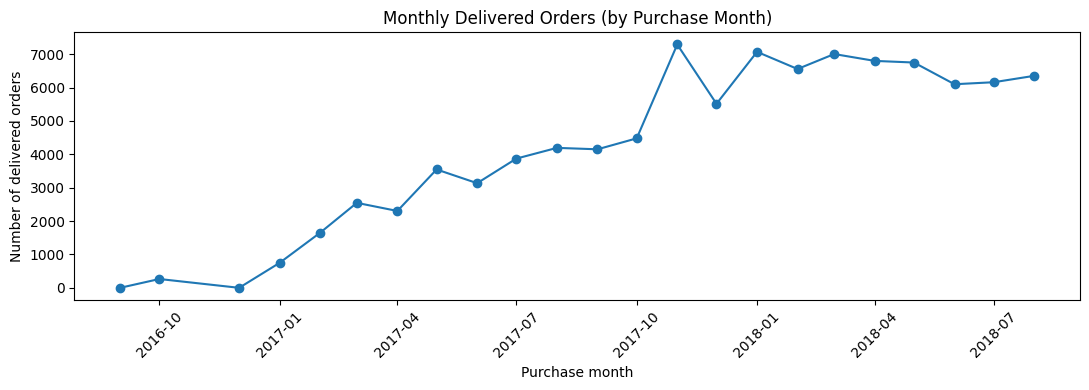

In [11]:
orders_delivered['purchase_month'] = (
    orders_delivered['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
)
monthly_orders = (
    orders_delivered.groupby('purchase_month', as_index=False)
    .agg(total_orders=('order_id', 'nunique'))
    .sort_values('purchase_month')
)
display(monthly_orders.tail(10))

plt.figure(figsize=(11, 4))
plt.plot(monthly_orders['purchase_month'], monthly_orders['total_orders'], marker='o')
plt.title('Monthly Delivered Orders (by Purchase Month)')
plt.xlabel('Purchase month')
plt.ylabel('Number of delivered orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10) Join customers — pahami grain dan unique ID

Di Olist:
- `customer_id` biasanya mewakili satu **customer record untuk sebuah order**.
- `customer_unique_id` digunakan untuk mengidentifikasi **orang yang sama pada beberapa orders**.

Bisa gabungkan `orders` dengan `customers` menggunakan `customer_id`. `validate='many_to_one'` memastikan sisi `customers.customer_id` memang unik. Jika tidak, Pandas memberi error daripada diam-diam menduplikasi baris.

In [12]:
orders_with_customers = orders_delivered.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_state']],
    on='customer_id',
    how='left',
    validate='many_to_one'
)

print('Rows before JOIN:', len(orders_delivered))
print('Rows after JOIN :', len(orders_with_customers))
print('Missing customer_unique_id after JOIN:',
      orders_with_customers['customer_unique_id'].isna().sum())
display(orders_with_customers[['order_id', 'customer_unique_id', 'customer_state']].head())

Rows before JOIN: 96478
Rows after JOIN : 96478
Missing customer_unique_id after JOIN: 0


,order_id,customer_unique_id,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,BA
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,SP


## 11) Mini customer analysis — repeat purchase


**Repeat customer** = `customer_unique_id` dengan **lebih dari satu delivered order** dalam periode yang tercatat.  
**Repeat customer rate** = repeat customers / all customers with at least one delivered order.

In [13]:
purchases_per_customer = (
    orders_with_customers
    .dropna(subset=['customer_unique_id'])
    .groupby('customer_unique_id')['order_id']
    .nunique()
)
unique_customers = len(purchases_per_customer)
repeat_customers = int((purchases_per_customer > 1).sum())
repeat_customer_rate = (repeat_customers / unique_customers * 100
                        if unique_customers else 0)

print(f'Unique customers with delivered orders: {unique_customers:,}')
print(f'Repeat customers (>1 delivered order): {repeat_customers:,}')
print(f'Repeat customer rate (observed): {repeat_customer_rate:.2f}%')

Unique customers with delivered orders: 93,358
Repeat customers (>1 delivered order): 2,801
Repeat customer rate (observed): 3.00%


## 12) Warning: JOIN order_items dan order_payments

Agregat **per order**:
- `items`: `SUM(price)` = nilai item (tanpa ongkir)
- `payments`: `SUM(payment_value)` = jumlah pembayaran, bisa mencakup ongkir dan komponen lain

Kedua metrik **tidak identik**, jadi kita harus memilih definisi revenue yang jelas.

In [14]:
item_count = items.groupby('order_id').size()
payment_count = payments.groupby('order_id').size()

print('Orders with multiple item rows:', int((item_count > 1).sum()))
print('Orders with multiple payment rows:', int((payment_count > 1).sum()))
print('Maximum items for a single order:', int(item_count.max()))
print('Maximum payment records for a single order:', int(payment_count.max()))

Orders with multiple item rows: 9803
Orders with multiple payment rows: 2961
Maximum items for a single order: 21
Maximum payment records for a single order: 29
